In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

np.random.seed(42)

In [2]:
rows = 500

store = np.random.randint(1,6,rows)

item_price = np.random.randint(20,300,rows)

advertising = np.random.randint(1000,10000,rows)

season = np.random.choice(["Summer","Winter","Rainy"],rows)

holiday = np.random.choice(["Yes","No"],rows)

customers = np.random.randint(50,500,rows)

sales = (
item_price*customers*0.4
+ advertising*2
+ np.random.randint(-5000,5000,rows)
)

df = pd.DataFrame({

"Store":store,
"ItemPrice":item_price,
"Advertising":advertising,
"Season":season,
"Holiday":holiday,
"Customers":customers,
"Sales":sales

})

df.head()

,Store,ItemPrice,Advertising,Season,Holiday,Customers,Sales
0,4,81,1768,Summer,Yes,283,8653.2
1,5,103,6490,Winter,No,139,21885.8
2,3,236,7645,Winter,Yes,363,50672.2
3,5,206,6083,Rainy,No,103,16112.2
4,5,38,6232,Winter,Yes,61,15959.2


In [3]:
df.to_csv("sales_dataset.csv",index=False)

print("Dataset Saved")

Dataset Saved


In [4]:
print(df.head())

print(df.shape)

df.info()

   Store  ItemPrice  Advertising  Season Holiday  Customers    Sales
0      4         81         1768  Summer     Yes        283   8653.2
1      5        103         6490  Winter      No        139  21885.8
2      3        236         7645  Winter     Yes        363  50672.2
3      5        206         6083   Rainy      No        103  16112.2
4      5         38         6232  Winter     Yes         61  15959.2
(500, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Store        500 non-null    int64  
 1   ItemPrice    500 non-null    int64  
 2   Advertising  500 non-null    int64  
 3   Season       500 non-null    object 
 4   Holiday      500 non-null    object 
 5   Customers    500 non-null    int64  
 6   Sales        500 non-null    float64
dtypes: float64(1), int64(4), object(2)
memory usage: 27.5+ KB


In [5]:
df.isnull().sum()

,0
Store,0
ItemPrice,0
Advertising,0
Season,0
Holiday,0
Customers,0
Sales,0


In [6]:
df.describe()

,Store,ItemPrice,Advertising,Customers,Sales
count,500.000000,500.00000,500.000000,500.000000,500.000000
mean,2.970000,153.48200,5508.094000,273.500000,27596.313600
std,1.425891,79.34116,2661.455183,131.807634,14295.339933
min,1.000000,20.00000,1001.000000,50.000000,1480.000000
25%,2.000000,83.50000,3142.000000,158.000000,17027.250000
50%,3.000000,155.50000,5353.500000,265.500000,25032.500000
75%,4.000000,221.25000,7965.250000,394.500000,36304.750000
max,5.000000,296.00000,9996.000000,499.000000,76325.600000


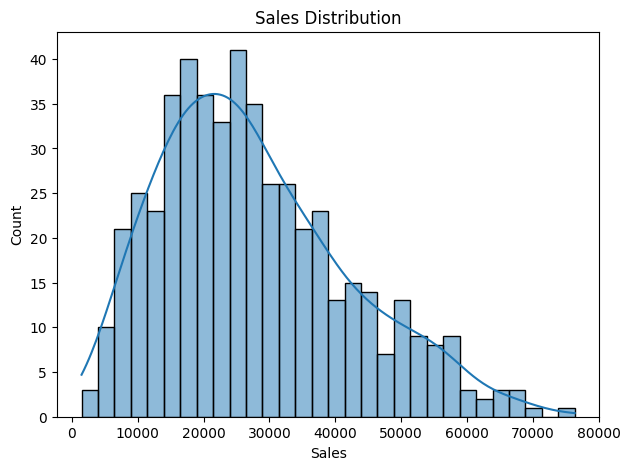

In [7]:
plt.figure(figsize=(7,5))

sns.histplot(df["Sales"],bins=30,kde=True)

plt.title("Sales Distribution")

plt.show()

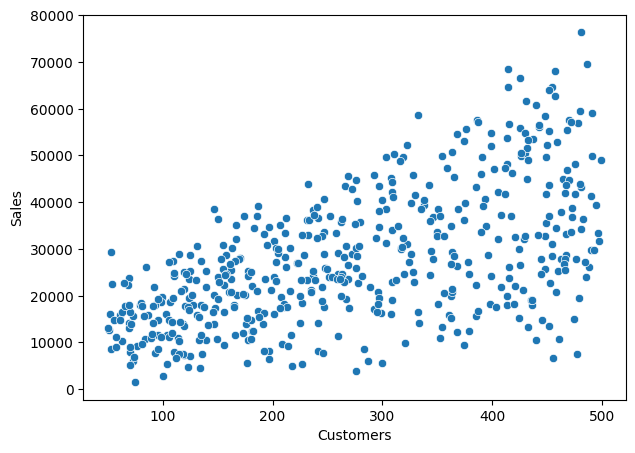

In [8]:
plt.figure(figsize=(7,5))

sns.scatterplot(x="Customers",y="Sales",data=df)

plt.show()

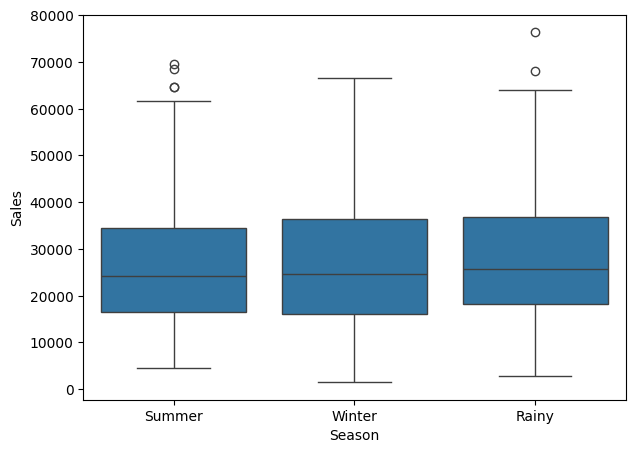

In [9]:
plt.figure(figsize=(7,5))

sns.boxplot(x="Season",y="Sales",data=df)

plt.show()

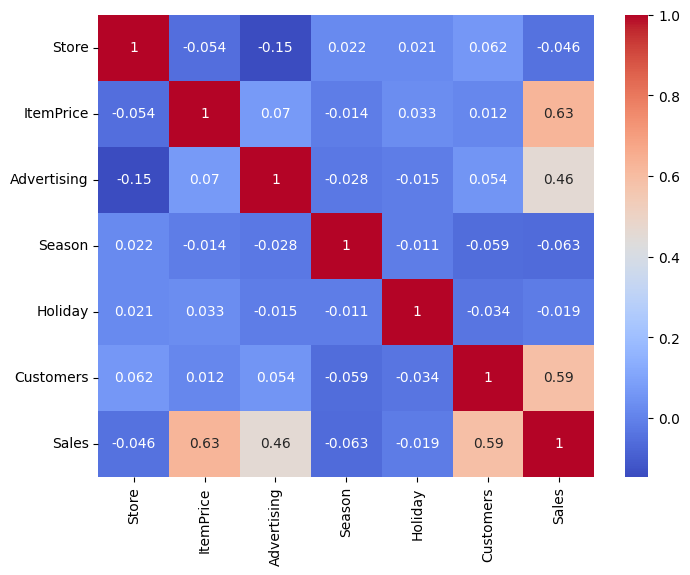

In [11]:
temp=df.copy()

encoder=LabelEncoder()

temp["Season"]=encoder.fit_transform(temp["Season"])

temp["Holiday"]=encoder.fit_transform(temp["Holiday"])

plt.figure(figsize=(8,6))

sns.heatmap(temp.corr(),annot=True,cmap="coolwarm")

plt.show()

In [12]:
encoder=LabelEncoder()

df["Season"]=encoder.fit_transform(df["Season"])

df["Holiday"]=encoder.fit_transform(df["Holiday"])

In [13]:
X=df.drop("Sales",axis=1)

y=df["Sales"]

In [14]:
X_train,X_test,y_train,y_test=train_test_split(

X,
y,
test_size=0.2,
random_state=42

)

In [15]:
model=RandomForestRegressor(random_state=42)

model.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [16]:
prediction=model.predict(X_test)

In [17]:
print("MAE =",mean_absolute_error(y_test,prediction))

print("RMSE =",np.sqrt(mean_squared_error(y_test,prediction)))

print("R2 Score =",r2_score(y_test,prediction))

MAE = 3362.215380000001
RMSE = 4215.459350628463
R2 Score = 0.9139980008839853


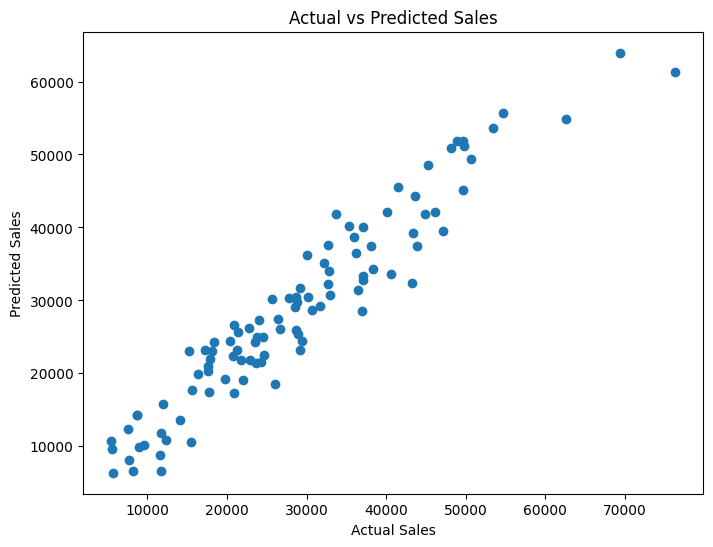

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,prediction)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

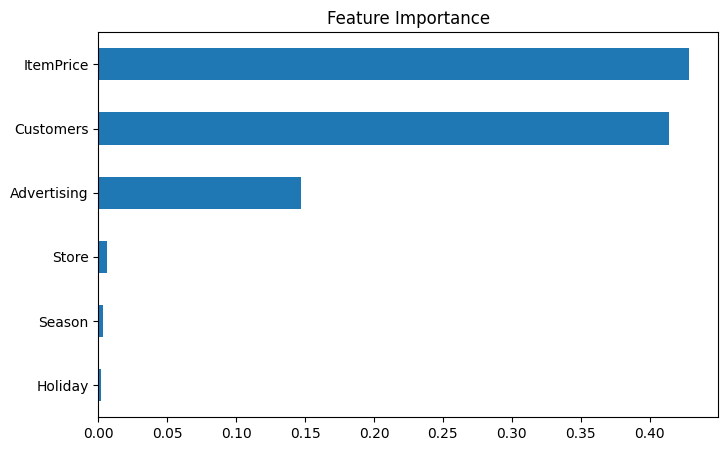

In [19]:
importance=pd.Series(model.feature_importances_,index=X.columns)

importance=importance.sort_values()

plt.figure(figsize=(8,5))

importance.plot(kind="barh")

plt.title("Feature Importance")

plt.show()

In [20]:
result=pd.DataFrame({

"Actual Sales":y_test.values,

"Predicted Sales":prediction

})

result.head(10)

,Actual Sales,Predicted Sales
0,45328.0,48503.972
1,28620.0,30450.806
2,26649.6,26133.360
3,15172.0,23119.666
4,21742.6,21835.198
5,24267.6,21546.516
6,36416.0,31411.910
7,49646.0,45197.470
8,26359.0,27426.906
9,15655.2,17674.970
